In [2]:
!pip uninstall -y datasets huggingface_hub fsspec
!pip install datasets==2.19.2 huggingface_hub==0.23.4 fsspec==2024.3.1

Found existing installation: datasets 2.19.2
Uninstalling datasets-2.19.2:
  Successfully uninstalled datasets-2.19.2
Found existing installation: huggingface-hub 0.23.4
Uninstalling huggingface-hub-0.23.4:
  Successfully uninstalled huggingface-hub-0.23.4
Found existing installation: fsspec 2024.3.1
Uninstalling fsspec-2024.3.1:
  Successfully uninstalled fsspec-2024.3.1
  Using cached datasets-2.19.2-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-0.23.4-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2024.3.1-py3-none-any.whl.metadata (6.8 kB)
Using cached datasets-2.19.2-py3-none-any.whl (542 kB)
Using cached huggingface_hub-0.23.4-py3-none-any.whl (402 kB)
Using cached fsspec-2024.3.1-py3-none-any.whl (171 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggi

In [3]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import re

MAX_LEN = 128

raw = load_dataset("yelp_polarity")
N_TRAIN = 100_000
N_TEST = 20_000 # VAL + TEST

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
splits = {
    split: raw[split].shuffle(seed=42).select(range(n))
    for split, n in {
        "train": N_TRAIN,
        "test": N_TEST,
    }.items()
}

train_texts, train_labels = splits["train"]["text"], splits["train"]["label"]
test_texts, test_labels = splits["test"]["text"], splits["test"]["label"]

val_texts, test_texts, val_labels, test_labels = (
    train_test_split(
        test_texts, test_labels, test_size=0.5, random_state=42
        )
    )

def print_distributions():
  for name, labels in {
      "Train": train_labels,
      "Validation": val_labels,
      "Test": test_labels
  }.items():
    print(f"\n {name} distribution.")
    print(f" Positive reviews: {sum(labels)/len(labels):.2%}.")

print_distributions()


 Train distribution.
 Positive reviews: 49.79%.

 Validation distribution.
 Positive reviews: 49.62%.

 Test distribution.
 Positive reviews: 50.27%.


In [5]:
def tokenize(text):
  text = text.lower()
  text = re.sub(r'<[^>]+>', ' ', text)
  text = re.sub(r'[^a-z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text.split()

from collections import Counter

def build_vocab(token_lists, min_freq=2): # We exclude all words that appear only once
  counter = Counter(token for tokens in token_lists for token in tokens)
  vocab = {
      token: idx + 2
      for idx, (token, count) in enumerate(counter.items())
      if count >= min_freq
  }
  vocab.update({"<PAD>": 0, "<UNK>": 1})
  return vocab

def tokens_to_ids(tokens, vocab):
  return [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]

def pad(seq, max_len=MAX_LEN, pad_value=0):
  len_diff = max_len - len(seq)
  if len_diff > 0:
    return seq + [pad_value] * len_diff
  else:
    return seq[:max_len]

def process_texts(texts, vocab, max_len=MAX_LEN):
  return [pad(tokens_to_ids(tokenize(text), vocab)) for text in texts]

train_tokens = [tokenize(t) for t in train_texts]
vocab = build_vocab(train_tokens)

train_ids = process_texts(train_texts, vocab)
val_ids = process_texts(val_texts, vocab)
test_ids = process_texts(test_texts, vocab)

In [6]:
import torch
# Data Loaders Preparation
BATCH_SIZE = 1 << 10

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

def to_loader(input_ids, labels, batch_size=BATCH_SIZE, shuffle=False):
  x_tensor = torch.tensor(input_ids, dtype=torch.long)
  y_tensor = torch.tensor(labels, dtype=torch.long)
  return torch.utils.data.DataLoader(
      torch.utils.data.TensorDataset(x_tensor, y_tensor),
      batch_size=batch_size,
      shuffle=shuffle)

train_loader = to_loader(train_ids, train_labels, BATCH_SIZE, shuffle=True)
val_loader   = to_loader(val_ids, val_labels, BATCH_SIZE)
test_loader  = to_loader(test_ids, test_labels, BATCH_SIZE)

In [7]:
from time import time

if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

print(f"Working on {device}")

def train_model(net, train_loader, val_loader, epochs=1000, lr=.001, log_every=10):
  print(f"Working on {device}")
  net = net.to(device)
  optimizer = torch.optim.Adam(net.parameters(), lr=lr)
  criterion = torch.nn.BCEWithLogitsLoss()
  train_loss_history = []
  val_loss_history = []
  train_acc_history = []
  val_acc_history = []

  start_time = time()

  for epoch in range(epochs):
    net.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for batch_inputs, batch_labels in train_loader:
      batch_inputs = batch_inputs.to(device)
      batch_labels = batch_labels.to(device).float()

      optimizer.zero_grad()
      logits = net(batch_inputs)
      loss = criterion(logits, batch_labels)
      loss.backward()
      optimizer.step()

      train_loss_sum += loss.item() * batch_inputs.size(0)
      preds = (torch.sigmoid(logits) > 0.5).float()
      train_correct += (preds == batch_labels).sum().item()
      train_total += batch_inputs.size(0)

    avg_train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_acc)

    net.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for batch_inputs, batch_labels in val_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device).float()

        logits = net(batch_inputs)
        loss = criterion(logits, batch_labels)

        val_loss_sum += loss.item() * batch_inputs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        val_correct += (preds == batch_labels).sum().item()
        val_total += batch_inputs.size(0)

    avg_val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    val_loss_history.append(avg_val_loss)
    val_acc_history.append(val_acc)

    if epoch % log_every == 0:
      print(f"Epoch {epoch:03d} | "
            f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

  end_time = time()
  print(f"Elapsed time: {end_time - start_time:.2f} seconds")

  return train_loss_history, val_loss_history, train_acc_history, val_acc_history


Working on cuda


In [8]:
import matplotlib.pyplot as plt

def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
  fig, axs = plt.subplots(1, 2, figsize=(14, 5))

  # Plot Loss
  axs[0].plot(train_loss, label="Train Loss", color='blue')
  axs[0].plot(val_loss, label="Val Loss", color='orange')
  axs[0].set_title("Loss per Epoch")
  axs[0].set_xlabel("Epoch")
  axs[0].set_ylabel("Average Loss")
  axs[0].grid(True)
  axs[0].legend()

  # Plot Accuracy
  axs[1].plot(train_acc, label="Train Accuracy", color='green')
  axs[1].plot(val_acc, label="Val Accuracy", color='red')
  axs[1].set_title("Accuracy per Epoch")
  axs[1].set_xlabel("Epoch")
  axs[1].set_ylabel("Accuracy")
  axs[1].grid(True)
  axs[1].legend()

  plt.tight_layout()
  plt.show()

Working on cuda
Epoch 000 | Train Loss: 0.7007, Acc: 0.4979 | Val Loss: 0.6985, Acc: 0.4962
Epoch 010 | Train Loss: 0.6517, Acc: 0.6052 | Val Loss: 0.6466, Acc: 0.6161
Epoch 020 | Train Loss: 0.5326, Acc: 0.7709 | Val Loss: 0.5270, Acc: 0.7757
Epoch 030 | Train Loss: 0.4468, Acc: 0.8232 | Val Loss: 0.4453, Acc: 0.8217
Epoch 040 | Train Loss: 0.3886, Acc: 0.8521 | Val Loss: 0.3905, Acc: 0.8478
Epoch 050 | Train Loss: 0.3455, Acc: 0.8712 | Val Loss: 0.3507, Acc: 0.8667
Epoch 060 | Train Loss: 0.3124, Acc: 0.8856 | Val Loss: 0.3211, Acc: 0.8786
Epoch 070 | Train Loss: 0.2864, Acc: 0.8954 | Val Loss: 0.2989, Acc: 0.8876
Epoch 080 | Train Loss: 0.2657, Acc: 0.9032 | Val Loss: 0.2822, Acc: 0.8931
Epoch 090 | Train Loss: 0.2491, Acc: 0.9090 | Val Loss: 0.2696, Acc: 0.8969
Epoch 100 | Train Loss: 0.2355, Acc: 0.9141 | Val Loss: 0.2604, Acc: 0.9018
Epoch 110 | Train Loss: 0.2243, Acc: 0.9178 | Val Loss: 0.2536, Acc: 0.9041
Epoch 120 | Train Loss: 0.2148, Acc: 0.9215 | Val Loss: 0.2488, Acc: 0.9

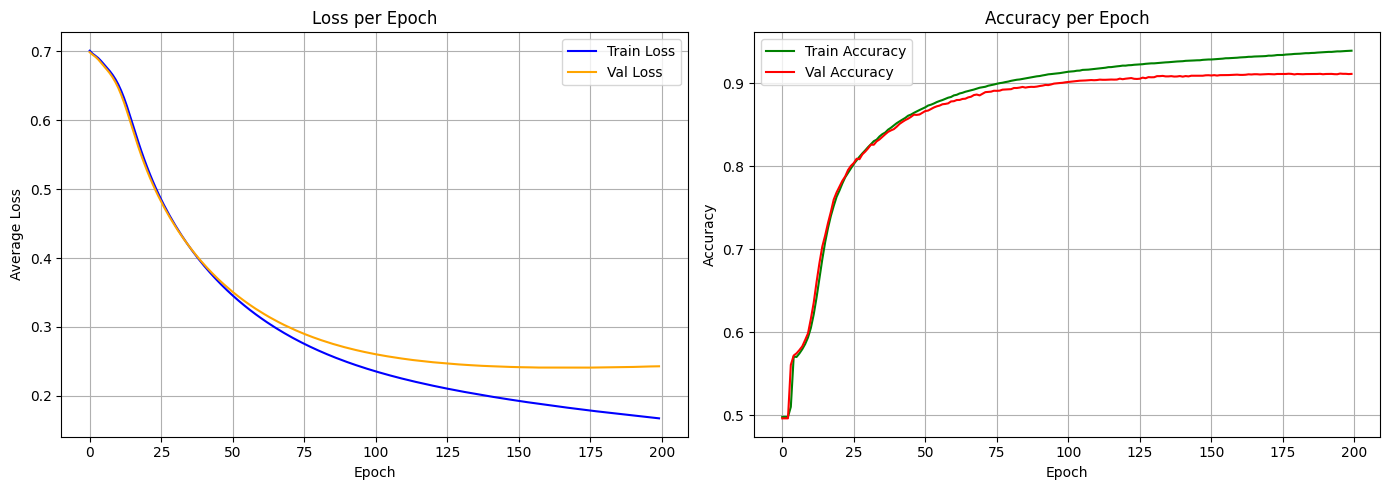

In [9]:
feature_cnt = 1
vocab_len = max(vocab.values()) + 1

class Net_1(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_len, feature_cnt)
    self.classifier = torch.nn.Linear(feature_cnt, 1)

  def forward(self, index):                     # batch, words
    features = self.embedding(index)            # batch, words, features
    features = features.mean(-2)                # batch, features
    classification = self.classifier(features)  # batch, 1
    logits = classification.squeeze(-1)
    return logits

net_1 = Net_1()

train_loss, val_loss, train_acc, val_acc = train_model(net_1, train_loader, val_loader, epochs = 200)
plot_training_curves(train_loss, val_loss, train_acc, val_acc)


In [10]:
import numpy as np

embedding_weights = net_1.embedding.weight.detach().cpu().numpy().squeeze()

id2token = {idx: token for token, idx in vocab.items()}
valid_indices = np.array(
    [
        idx
        for idx in range(2, len(embedding_weights))
        if idx in id2token
    ]
)

valid_embeddings = embedding_weights[valid_indices]

partitioned_pos = np.argpartition(valid_embeddings, -20)[-20:]
partitioned_neg = np.argpartition(valid_embeddings, 19)[:20]

sorted_pos = partitioned_pos[np.argsort(-valid_embeddings[partitioned_pos])]
sorted_neg = partitioned_neg[np.argsort(valid_embeddings[partitioned_neg])]

top_pos_indices = valid_indices[sorted_pos]
top_neg_indices = valid_indices[sorted_neg]

def print_words_with_embeddings(indices, title):
  print(f"\n{title}")
  for idx in indices:
    word = id2token[int(idx)]
    value = embedding_weights[int(idx)]
    print(f"{word:15} <- {value:.4f}")

print_words_with_embeddings(top_pos_indices, "Top 20 most positive words:")
print_words_with_embeddings(top_neg_indices, "Top 20 most negative words:")


Top 20 most positive words:
delicious       <- 13.2235
excellent       <- 12.7576
phenomenal      <- 12.7009
awesome         <- 12.2002
fantastic       <- 11.9967
pleasantly      <- 11.8967
amazing         <- 11.7529
perfection      <- 11.6419
gem             <- 11.4302
ngreat          <- 11.3560
incredible      <- 11.2053
yum             <- 11.0856
perfect         <- 10.7907
glad            <- 10.2746
perfectly       <- 9.9910
yummy           <- 9.9270
addicted        <- 9.8642
wonderful       <- 9.5822
pleased         <- 9.5092
superb          <- 9.4010

Top 20 most negative words:
mediocre        <- -16.5915
bland           <- -16.3095
worst           <- -15.1473
horrible        <- -14.6822
disgusting      <- -14.6809
disappointing   <- -14.3393
terrible        <- -14.3263
meh             <- -13.8851
overpriced      <- -13.3517
tasteless       <- -12.8738
awful           <- -12.5062
unfortunately   <- -12.2981
unimpressed     <- -12.1688
poorly          <- -12.1054
rude            

In [11]:
texts = [
    "I love this",
    "I like this",
    "I do not like this",
    "I don't like this",
    "This is terrible",
    "Thank you so much!",
    "I hate this",
    "I don't hate this",
    "This sucks!"
]

input_ids = process_texts(texts, vocab)
input_tensor = torch.tensor(input_ids).to(next(net_1.parameters()).device)

net_1.eval()
with torch.no_grad():
  logits = net_1(input_tensor).squeeze()
  probs = torch.sigmoid(logits)

for text, prob in zip(texts, probs):
    print(f"{text:30} <- predicted probability of class 1: {prob.item():.4f}")

I love this                    <- predicted probability of class 1: 0.7463
I like this                    <- predicted probability of class 1: 0.5497
I do not like this             <- predicted probability of class 1: 0.3569
I don't like this              <- predicted probability of class 1: 0.4834
This is terrible               <- predicted probability of class 1: 0.1831
Thank you so much!             <- predicted probability of class 1: 0.7319
I hate this                    <- predicted probability of class 1: 0.4095
I don't hate this              <- predicted probability of class 1: 0.3470
This sucks!                    <- predicted probability of class 1: 0.2298


In [12]:
MAX_LEN = 256

def pair_every_sentence_with_random(texts, labels, seed=42):
  np.random.seed(seed)
  n = len(texts)

  texts_np = np.array(texts)

  random_labels = np.random.randint(0, n, size=n)
  augmented_texts = texts_np[random_labels] + " " + texts_np

  extended_texts = list(texts) + list(augmented_texts)
  extended_labels = list(labels) + list(labels)
  return extended_texts, extended_labels

train_texts, train_labels = pair_every_sentence_with_random(train_texts, train_labels)
val_texts, val_labels = pair_every_sentence_with_random(val_texts, val_labels)
test_texts, test_labels = pair_every_sentence_with_random(test_texts, test_labels)

train_ids = process_texts(train_texts, vocab, MAX_LEN)
val_ids = process_texts(val_texts, vocab, MAX_LEN)
test_ids = process_texts(test_texts, vocab, MAX_LEN)

train_loader = to_loader(train_ids, train_labels, BATCH_SIZE, shuffle=True)
val_loader = to_loader(val_ids, val_labels, BATCH_SIZE)
test_loader = to_loader(test_ids, test_labels, BATCH_SIZE)


In [13]:
feature_cnt = 16

class Attention(torch.nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self, features):                                  # batch, words, features
    batch = features.size(0)
    words = features.size(1)
    energies = torch.zeros((batch, 1, words))                   # batch, 1, words
    weights = torch.nn.functional.softmax(energies, -1)         # batch, 1, words
    features = weights @ features                               # batch, 1, features
    return features

class Net_Towards_Attention(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_len, feature_cnt)
    self.attention = Attention()
    self.classifier = torch.nn.Linear(feature_cnt, 1)

  def forward(self, index):                                     # batch, words
    features = self.embedding(index)                            # batch, words, features
    features = self.attention(features)                         # batch, 1, features
    classifications = self.classifier(features)                 # batch, 1, 1

    logits = classifications.squeeze(-1).squeeze(-1)            # batch
    return logits


Working on cuda
Epoch 000 | Train Loss: 0.6865, Acc: 0.5506 | Val Loss: 0.6704, Acc: 0.6030
Epoch 010 | Train Loss: 0.4932, Acc: 0.7649 | Val Loss: 0.5141, Acc: 0.7522
Epoch 020 | Train Loss: 0.4564, Acc: 0.7836 | Val Loss: 0.5368, Acc: 0.7411
Epoch 030 | Train Loss: 0.4284, Acc: 0.7968 | Val Loss: 0.5924, Acc: 0.7298
Epoch 040 | Train Loss: 0.4100, Acc: 0.8050 | Val Loss: 0.6592, Acc: 0.7206
Elapsed time: 176.12 seconds


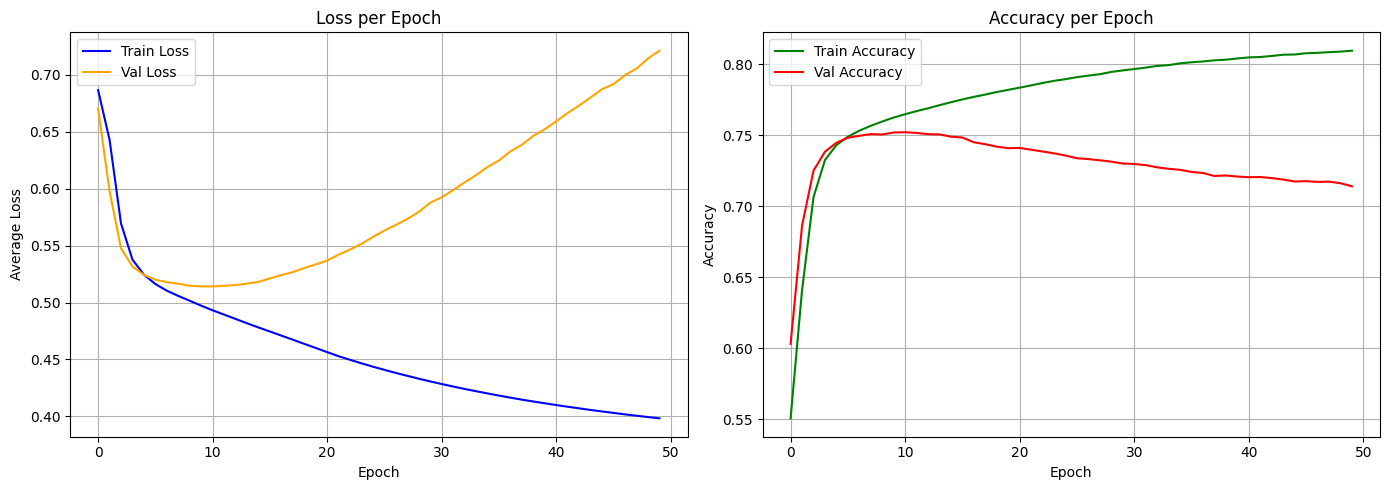

In [14]:
class Attention(torch.nn.Module):
  def __init__(self):
    super().__init__()
    # Introducing Learned Energies
    self.energy = torch.nn.Linear(feature_cnt, 1)

  def forward(self, features):                                  # batch, words, features
    batch = features.size(0)
    words = features.size(1)
    energies = self.energy(features)                            # batch, words, 1
    energies = energies.transpose(-2, -1)                       # batch, 1, words
    weights = torch.nn.functional.softmax(energies, -1)         # batch, 1, words
    features = weights @ features                               # batch, 1, features
    return features

class Net_Attention(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_len, feature_cnt)
    self.attention = Attention()
    self.classifier = torch.nn.Linear(feature_cnt, 1)

  def forward(self, index):                                     # batch, words
    features = self.embedding(index)                            # batch, words, features
    features = self.attention(features)                         # batch, 1, features
    classifications = self.classifier(features)                 # batch, 1, 1

    logits = classifications.squeeze(-1).squeeze(-1)            # batch
    return logits

net_att = Net_Attention()

train_loss, val_loss, train_acc, val_acc = train_model(net_att, train_loader, val_loader, epochs = 50)
plot_training_curves(train_loss, val_loss, train_acc, val_acc)